In [3]:
from sunpy.net import Fido, attrs as a

In [4]:
#Stixpy quicklook lightcurve:

In [5]:
from stixpy.net.client import STIXClient   # registers STIX with Fido

In [6]:
ql_query = Fido.search(a.Time('2020-06-05', '2020-06-07'), 
                       a.Instrument.stix, 
                       a.stix.DataProduct.ql_lightcurve)
ql_query

Start Time,End Time,Instrument,Level,DataType,DataProduct,Ver,Request ID
Time,Time,str4,str2,str2,str13,str3,str1
2020-06-05 00:00:00.000,2020-06-05 23:59:59.999,STIX,L1,QL,ql-lightcurve,V02,-
2020-06-06 00:00:00.000,2020-06-06 23:59:59.999,STIX,L1,QL,ql-lightcurve,V02,-
2020-06-07 00:00:00.000,2020-06-07 23:59:59.999,STIX,L1,QL,ql-lightcurve,V02,-


In [7]:
ql_files = Fido.fetch(ql_query)

Files Downloaded:   0%|          | 0/3 [00:00<?, ?file/s]

solo_L1_stix-ql-lightcurve_20200607_V02.fits:   0%|          | 0.00/1.70M [00:00<?, ?B/s]

solo_L1_stix-ql-lightcurve_20200605_V02.fits:   0%|          | 0.00/1.70M [00:00<?, ?B/s]

solo_L1_stix-ql-lightcurve_20200606_V02.fits:   0%|          | 0.00/1.70M [00:00<?, ?B/s]

In [8]:
from sunpy.timeseries import TimeSeries
from stixpy.timeseries import quicklook 

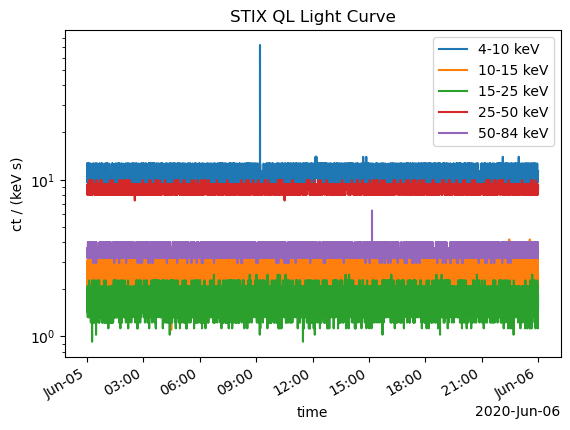

In [9]:
ql_lightcurves = TimeSeries(ql_files)
ql_lightcurves[0].peek()

In [10]:
import matplotlib.pyplot as plt
from datetime import datetime

In [11]:
combined = ql_lightcurves[0]
for lc in ql_lightcurves[1:]:
    combined = combined.concatenate(lc)

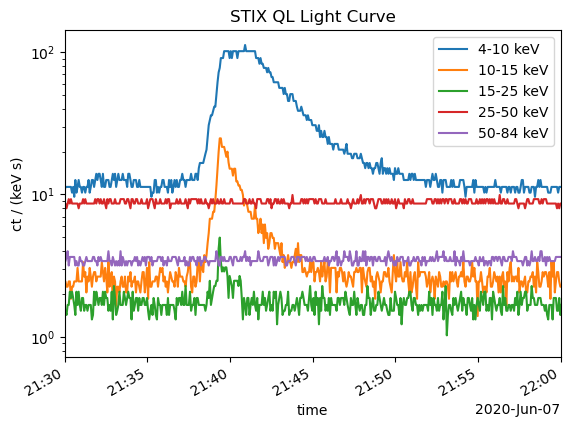

In [17]:
combined.plot()
plt.xlim(datetime(2020, 6, 7, 21, 30), datetime(2020, 6, 7, 22, 0))
plt.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/stix_20200607_2130.png")

In [ ]:
#GOES XRS lightcurve:

In [16]:
from sunpy import timeseries as ts

In [18]:
result = Fido.search(a.Time('2024-05-14 00:00', '2024-05-14 23:59'),
                     a.Instrument("XRS"),
                     a.goes.SatelliteNumber(16))
result

Start Time,End Time,Instrument,Physobs,Source,Provider,Resolution,SatelliteNumber
Time,Time,str3,str10,str4,str4,str5,int64
2024-05-14 00:00:00.000,2024-05-14 23:59:59.999,XRS,irradiance,GOES,NOAA,flx1s,16
2024-05-14 00:00:00.000,2024-05-14 23:59:59.999,XRS,irradiance,GOES,NOAA,avg1m,16


In [19]:
files = Fido.fetch(result)

Files Downloaded:   0%|          | 0/2 [00:00<?, ?file/s]

sci_xrsf-l2-avg1m_g16_d20240514_v2-2-1.nc:   0%|          | 0.00/299k [00:00<?, ?B/s]

sci_xrsf-l2-flx1s_g16_d20240514_v2-2-1.nc:   0%|          | 0.00/3.31M [00:00<?, ?B/s]

In [20]:
goes = ts.TimeSeries(files, concatenate=True)

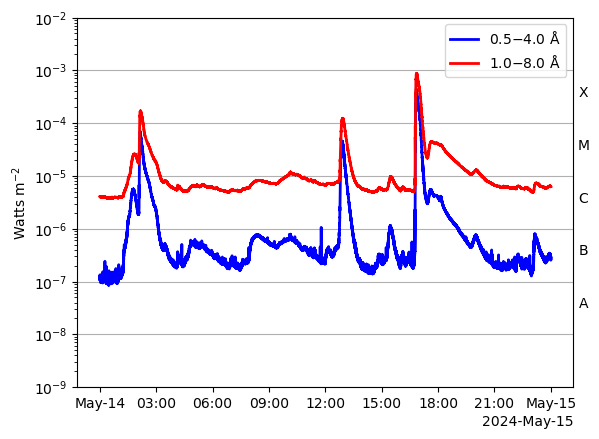

In [33]:
goes.plot()
plt.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/goes_20240514.png")

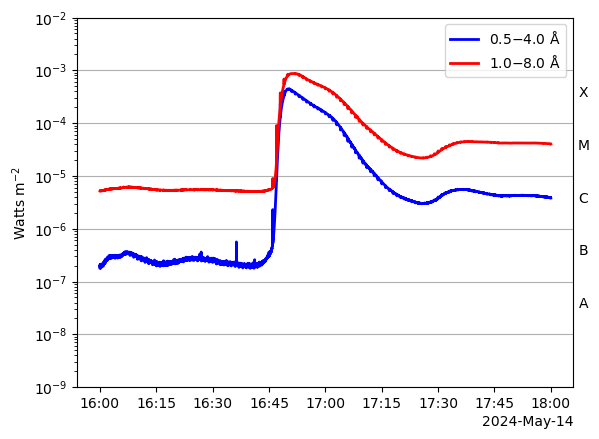

In [34]:
flare = goes.truncate("2024-05-14 16:00", "2024-05-14 18:00")
flare.plot()
plt.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/goes_20240514_singleflare.png")

In [1]:
import stixpy
stixpy.__version__

'0.2.0rc2.dev9+g977877057'

In [27]:
import sunpy
sunpy.__version__

'7.1.2'

In [2]:
pip install git+https://github.com/TCDSolar/stixpy.git

  Cloning https://github.com/TCDSolar/stixpy.git to C:\Users\derva\AppData\Local\Temp\pip-req-build-7bfi_icy
  Resolved https://github.com/TCDSolar/stixpy.git to commit 9778770579f031e819671a4d5ed74968b41f2a5d
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached sunpy-7.1.2-cp312-abi3-win_amd64.whl.metadata (12 kB)
Using cached sunpy-7.1.2-cp312-abi3-win_amd64.whl (3.7 MB)
  Created wheel for stixpy: filename=stixpy-0.2.0rc2.dev9+g977877057-py3-none-any.whl size=960864 sha256=697c959d7dc8288c953df50b9eb150909b65b09970487970be1790e1dc6411fb
  Stored in directory: C:\Users\derva\AppData\Local\Temp\pip-ephem-wheel-cache-n941mfi2\wheels\97\79\60\a6fbd832dd79b54ab6d74a531b963ac4d4636723d7a464854a
Success

  Running command git clone --filter=blob:none --quiet https://github.com/TCDSolar/stixpy.git 'C:\Users\derva\AppData\Local\Temp\pip-req-build-7bfi_icy'
  Running command git submodule update --init --recursive -q
